# Projects (30 pts):

Suppose $S_1(t)$ and $S_2(t)$ are independent stock processes with equal volatility. $S_1(0)=S_2(0)=100.$
The contract at maturity pays the value of the most expensive stock: $V(T)=\max_i\{S_1(T),S_2(T)\}.$
* What is the formula for the fair value of the contract, $V(0)$?         
* Derive the partial differential equation for this contract              
* Solve the resultant PDE using Finite Difference Method                   
* Compare the results obtained through solving the PDE with Monte Carlo Method 

$$V(0) = S_1(0) \Phi(d_1) + S_2(0) \Phi(d_2)$$

$d_1 = \frac{\ln(S_1/S_2) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$d_2 = \frac{\ln(S_2/S_1) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$\hat{\sigma} = \sigma\sqrt{2}$

$\Phi$ a standard normális eloszlásfüggvény.

$$V(0) = 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) + 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) = 200 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right)$$

## Simple black scholes numerical scheme for 1 stock

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
K = 100.0
T = 1.0
R = 0.05
SIGMA = 0.20

x_min = -4.0
x_max = 4.0

n_x = 201
n_t = 4001

analitikus formula

In [3]:
def black_scholes_eu_call(S0, K, T, r, sigma):
    S0 = np.asarray(S0, dtype=float)

    if T == 0:
        return np.maximum(S0 - K, 0.0)

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return norm.cdf(d1) * S0 - K * np.exp(-r * T) * norm.cdf(d2)

In [4]:
def get_d1(n):
    return 0.5 * (np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), -1))

def get_d2(n):
    return (
        np.diag(np.ones(n - 1), 1)
        + np.diag(-2.0 * np.ones(n), 0)
        + np.diag(np.ones(n - 1), -1)
    )

def get_a(n, dx, r, sig):
    d  = -r * np.eye(n)
    d1 = (r - 0.5 * sig**2) / dx * get_d1(n)
    d2 = 0.5 * sig**2 / dx**2 * get_d2(n)
    return d + d1 + d2

## Perem- és végfeltételek

Európai call opció lejáratkori payoffja:

$
V(S,T)=\max(S-K,0)
$

Log-változóban, ahol \(S=K e^x\):

$
V(x,T)=K\max(e^x-1,0)
$

Bal oldali perem:
$
V(x_{\min},t)\approx 0
$

Jobb oldali perem:
$
V(x_{\max},t)\approx K\left(e^{x_{\max}}-e^{-r(T-t)}\right)
$

A numerikus rácsban ezeket előre beírjuk.

In [5]:
def call_boundary(grid, x_min, x_max, K, T, r):
    n_x, n_t = grid.shape

    x_values = np.linspace(x_min, x_max, n_x)
    t_values = np.linspace(0.0, T, n_t)

    # bal perem
    grid[0, :] = 0.0

    # jobb perem
    grid[-1, :] = K * (np.exp(x_max) - np.exp(-r * (T - t_values)))

    # terminal condition t = T
    grid[:, -1] = K * np.maximum(np.exp(x_values) - 1.0, 0.0)

    return grid

In [6]:
def create_and_run_explicit_BS(n_x, n_t):
    dx = (x_max - x_min) / (n_x - 1)
    dt = T / (n_t - 1)

    explicit_grid = np.zeros((n_x, n_t))
    explicit_grid = call_boundary(explicit_grid, x_min, x_max, K, T, R)

    matrix = np.eye(n_x) + dt * get_a(n_x, dx, R, SIGMA)

    for n in range(n_t - 1, 0, -1):
        explicit_grid[1:-1, n - 1] = (matrix @ explicit_grid[:, n])[1:-1]

    return explicit_grid

In [7]:
def plot_explicit_vs_analytic(n_x, n_t):
    grid = create_and_run_explicit_BS(n_x, n_t)

    x_values = np.linspace(x_min, x_max, n_x)
    spots = K * np.exp(x_values)

    numeric_t0 = grid[:, 0]
    analytic_t0 = black_scholes_eu_call(spots, K, T, R, SIGMA)

    plt.figure(figsize=(8, 5))
    plt.plot(spots, numeric_t0, "o-", markersize=3, label="Explicit FDM")
    plt.plot(spots, analytic_t0, "-", label="Analitikus Black-Scholes")

    up_lim = 5 * K
    plt.xlim(0, up_lim)
    plt.ylim(0, up_lim - K)

    plt.xlabel("Spot ár S")
    plt.ylabel("Opció értéke V(S,0)")
    plt.title("Európai call: numerikus vs analitikus")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

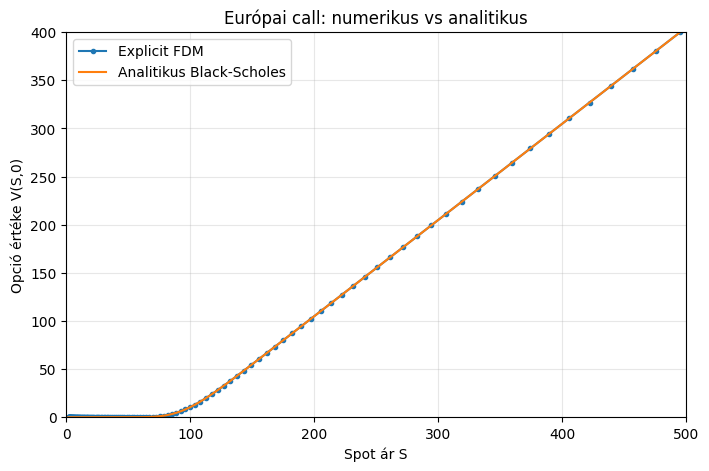

In [8]:
plot_explicit_vs_analytic(n_x=201, n_t=4001)

## Derive the partial differential equation for this contract 

Since $V=V(S_1,S_2,t)$

$$\frac{\partial V}{\partial t} + rS_1 \frac{\partial V}{\partial S_1} + rS_2 \frac{\partial V}{\partial S_2} + \frac{1}{2}\sigma^2 S_1^2 \frac{\partial^2 V}{\partial S_1^2} + \frac{1}{2}\sigma^2 S_2^2 \frac{\partial^2 V}{\partial S_2^2} - rV = 0$$

The boundary conditions:

$V(S_1,S_2,T)=max(S_1,S_2)$

$V(0,S_2,t)=S_2$

$V(S_1,0,t)=S_11$

## Numerical scheme

$$x = \log(S_1/K), \quad y = \log(S_2/K)$$

$$V = V(x, y, t).$$

$$-V_t = \left( r - \frac{\sigma^2}{2} \right) V_x + \left( r - \frac{\sigma^2}{2} \right) V_y + \frac{\sigma^2}{2} V_{xx} + \frac{\sigma^2}{2} V_{yy} - rV$$